In [120]:
import pandas as pd
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from sklearn.preprocessing import LabelEncoder

# 1. Carga de metadatos en Pandas
BASE_DIR = '/kaggle/input/datasets/yehongjiang/pokemon-sprites-images/pokemon_images'
CSV_PATH = os.path.join(BASE_DIR, 'pokedex.csv')
df_pokedex = pd.read_csv(CSV_PATH).dropna(subset=['type1', 'primary_color', 'legendary'])

# 2. Captura de rutas Frente y Espalda
SPRITES_DIR = os.path.join(BASE_DIR, 'sprites')
front_paths = glob.glob(os.path.join(SPRITES_DIR, "*", "front", "normal", "*.png"))
back_paths = glob.glob(os.path.join(SPRITES_DIR, "*", "back", "normal", "*.png"))
all_image_paths = front_paths + back_paths
print(f"Total de imágenes encontradas: {len(all_image_paths)}")

# 3. Match con el Pokedex CSV
pokedex_names = sorted(df_pokedex['name'].astype(str).unique(), key=len, reverse=True)
valid_rows = []
for path in all_image_paths:
    folder_name = path.split(os.sep)[-4] 
    orientation = 1 if "front" in path else 0 # 1 para Frente, 0 para Espalda
    for name in pokedex_names:
        if name.lower() in folder_name.lower():
            valid_rows.append({'image_path': path, 'name': name, 'orientation': orientation})
            break

df_images = pd.DataFrame(valid_rows)
filtered_df = pd.merge(df_images, df_pokedex, on='name', how='inner')
print(f"Vinculados con éxito: {len(filtered_df)} registros.")

# 4. Encoder de Tipos
type_encoder = LabelEncoder()
filtered_df['type_encoded'] = type_encoder.fit_transform(filtered_df['type1'])
NUM_TYPES = len(type_encoder.classes_)

# 5. Clase Dataset
class PokemonPyTorchDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe
        self.transform = transforms.Compose([
            transforms.Resize((96, 96)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Procesamiento del canal Alpha transparente sobre fondo blanco puro
        with Image.open(row['image_path']).convert("RGBA") as img:
            background = Image.new("RGBA", img.size, (255, 255, 255))
            alpha_composite = Image.alpha_composite(background, img).convert("RGB")
            
        tensor_img = self.transform(alpha_composite)
        type_lbl = torch.tensor(row['type_encoded'], dtype=torch.long)
        orient_lbl = torch.tensor(row['orientation'], dtype=torch.float32)
        
        return tensor_img, {"type": type_lbl, "orient": orient_lbl}

# 6. Instanciación del DataLoader
BATCH_SIZE = 128
pytorch_dataset = PokemonPyTorchDataset(filtered_df)
dataloader = DataLoader(pytorch_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)

print("DataLoader listo")

Total de imágenes encontradas: 5104
Vinculados con éxito: 5104 registros.
DataLoader listo


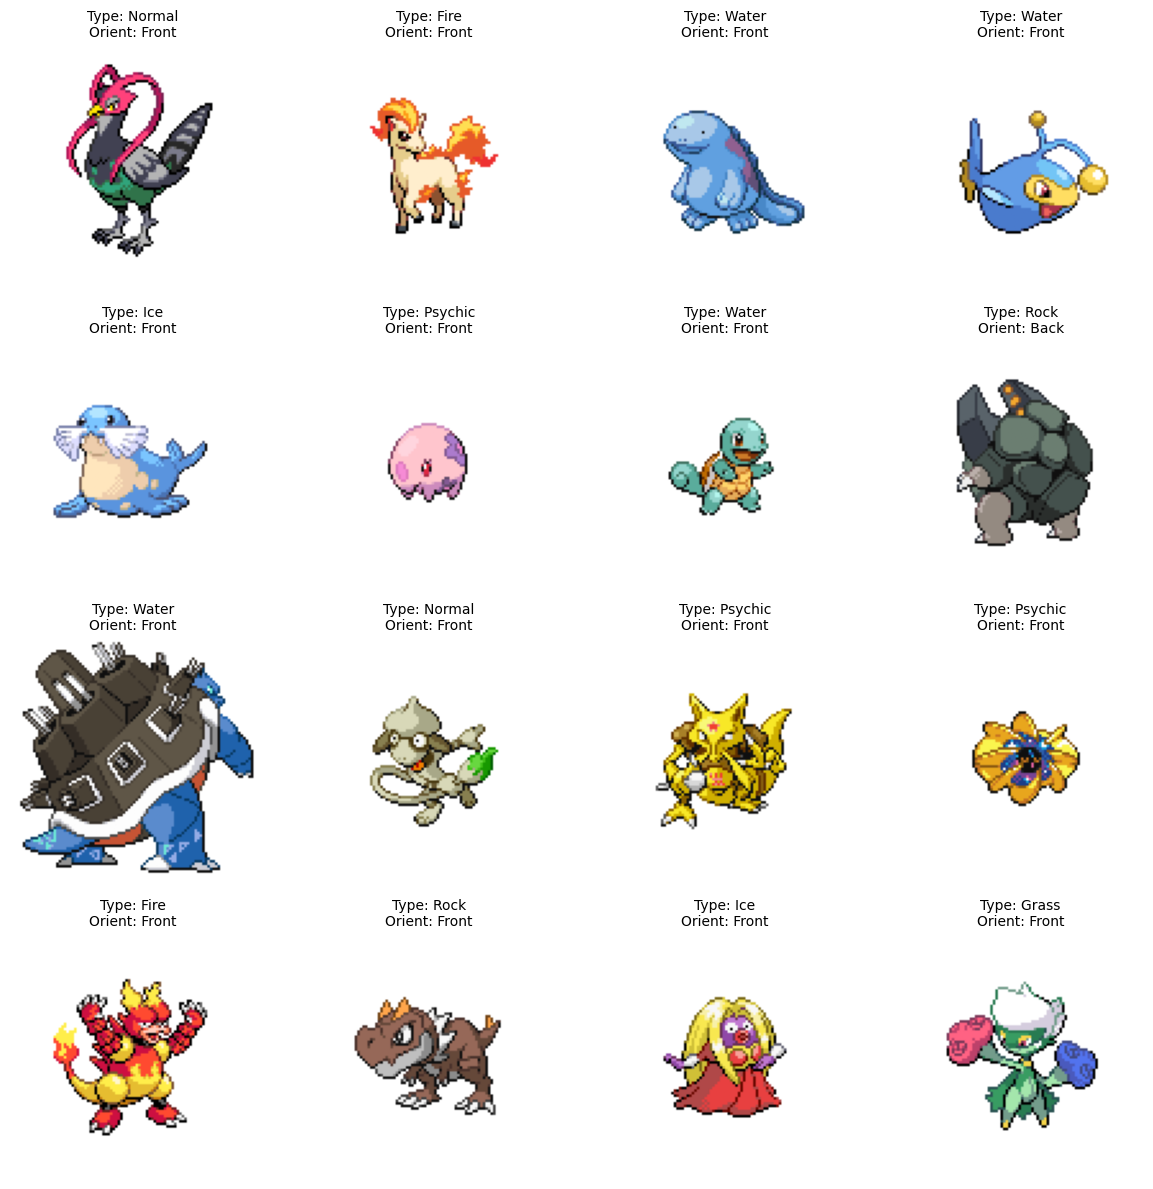

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Tomamos un lote del DataLoader de PyTorch
images, labels = next(iter(dataloader))

plt.figure(figsize=(12, 12))
# Vamos a graficar una cuadrícula de 16 imágenes de muestra
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    
    img = images[i].cpu().numpy()
    img = (img + 1.0) / 2.0
    
    img = np.transpose(img, (1, 2, 0))
    
    t_idx = labels["type"][i].item()
    o_idx = labels["orient"][i].item()
    
    type_str = type_encoder.inverse_transform([t_idx])[0]
    orient_str = "Front" if o_idx == 1.0 else "Back"
    
    plt.imshow(np.clip(img, 0.0, 1.0))
    plt.title(f"Type: {type_str}\nOrient: {orient_str}", fontsize=10)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [122]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    """
    Input: (N, dim_z, 1, 1), (N, n_labels)
    Output: (N, 3, 96, 96)
    """
    def __init__(self, dim_z, n_labels):
        super(Generator, self).__init__()

        self.dim_z = dim_z
        self.n_labels = n_labels

        self.latent_dim = dim_z + n_labels

        self.linear = nn.Sequential(
            nn.LazyConvTranspose2d(1024, kernel_size=6, stride=1, padding=0),
            nn.LeakyReLU(0.2),
        )

        self.backbone = nn.Sequential(*[
            self.upsample_block(512),
            self.upsample_block(256),
            self.upsample_block(128),
        ])

        self.gen = nn.Sequential(
            nn.LazyConvTranspose2d(3, kernel_size=4, stride=2, padding=1), 
            nn.Tanh()
        )

    def upsample_block(self, num_filters):
        layers = [
            nn.LazyConvTranspose2d(num_filters, kernel_size=4, stride=2, padding=1, bias=False), 
            nn.BatchNorm2d(num_filters),
            nn.LeakyReLU(0.2),
            nn.LazyConv2d(num_filters, kernel_size=3, stride=1, padding=1, bias=False), 
            nn.BatchNorm2d(num_filters),
            nn.LeakyReLU(0.2),
            nn.LazyConv2d(num_filters, kernel_size=3, stride=1, padding=1, bias=False), 
            nn.BatchNorm2d(num_filters),
            nn.LeakyReLU(0.2)
        ]
        return nn.Sequential(*layers)

    def forward(self, noise, labels):
        noise_with_labels = torch.concat((noise, labels[:, :, None, None]), dim=1)
        init_feat_map = self.linear(noise_with_labels)
        final_feat_map = self.backbone(init_feat_map)
        image = self.gen(final_feat_map)
        return image

# custom weights initialization called on netG and netD
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [123]:
class AdditiveGaussianNoise(nn.Module):
    def __init__(self, std=0.1, linear_decay_step=200000):
        super().__init__()
        self.std = std
        self.linear_decay = self.std / linear_decay_step

    def std_decay_step(self):
        self.std = max(0, self.std - self.linear_decay)

    def forward(self, x):
        if self.training:
            return x + torch.empty_like(x).normal_(std=self.std)
        else:
            return x

def decay_gauss_std(module):
    for m in module.modules():
        if isinstance(m, AdditiveGaussianNoise):
            m.std_decay_step()

In [124]:
from torch.nn.utils.parametrizations import spectral_norm

class Discriminator(nn.Module):
    """
    Input: (N, 3, 96, 96)
    Output: (adv label (N, 1), aux labels (N, n_labels)]
    """

    def __init__(self, n_labels, embed_dim=128):
        super(Discriminator, self).__init__()

        self.n_labels = n_labels

        self.backbone = nn.Sequential(*[
            self.downsample_block(3, 64),
            self.downsample_block(64, 128),
            self.downsample_block(128, 256),
            self.downsample_block(256, 512)
        ])

        self.adv_clf = nn.Sequential(
            AdditiveGaussianNoise(),
            spectral_norm(nn.Conv2d(512, 1, kernel_size=6, stride=1, padding=0)),
            nn.Sigmoid()  # binary label
        )

        self.aux_clf = nn.Sequential(
            AdditiveGaussianNoise(),
            spectral_norm(nn.Conv2d(512, self.n_labels, kernel_size=6, stride=1, padding=0)),
            nn.Sigmoid()  # multi-label
        )

    def downsample_block(self, in_channels, out_channels):
        layers = [
            AdditiveGaussianNoise(),
            spectral_norm(nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True)
        ]
        return nn.Sequential(*layers)

    def forward(self, images):
        feat_maps = self.backbone(images)

        adv_label = self.adv_clf(feat_maps).squeeze().unsqueeze(1)  # (N, 1)
        aux_labels = self.aux_clf(feat_maps).squeeze()  # (N, n_labels)
        if self.n_labels == 1:
            aux_labels = aux_labels.unsqueeze(1)

        return adv_label, aux_labels, feat_maps.reshape(images.size(0), -1)

In [125]:
# Adapt from https://github.com/POSTECH-CVLab/PyTorch-StudioGAN/blob/master/src/utils/losses.py#L162
class Data2DataCrossEntropyLoss(nn.Module):
  
    def __init__(self, num_classes, embed_dim=128, temperature=0.5, m_p=0.95):
        super(Data2DataCrossEntropyLoss, self).__init__()

        self.num_classes = num_classes
        self.embed_dim = embed_dim

        self.temperature = temperature
        self.m_p = m_p

        self.cosine_similarity = torch.nn.CosineSimilarity(dim=-1)

        self.project_head = nn.Sequential(
            nn.Linear(512 * 6 * 6, self.embed_dim * 2),  # manually set to the dim of feature map
            nn.ReLU(),
            nn.Linear(self.embed_dim * 2, self.embed_dim)
        )
        self.embedding = nn.Embedding(num_classes, 128)

    def calculate_similarity_matrix(self, x, y):
        v = self.cosine_similarity(x.unsqueeze(1), y.unsqueeze(0))
        return v

    def make_index_matrix(self, labels):
        labels = labels.detach().cpu().numpy()
        num_samples = labels.shape[0]
        mask_multi, target = np.ones([self.num_classes, num_samples]), 0.0

        for c in range(self.num_classes):
            c_indices = np.where(labels == c)
            mask_multi[c, c_indices] = target
        return torch.tensor(mask_multi).type(torch.long).to(device)

    def remove_diag(self, M):
        h, w = M.shape
        assert h==w, "h and w should be same"
        mask = np.ones((h, w)) - np.eye(h)
        mask = torch.from_numpy(mask)
        mask = (mask).type(torch.bool)
        return M[mask].view(h, -1)

    def forward(self, feat_map, label):
        embed = self.project_head(feat_map)
        embed = F.normalize(embed, dim=1)

        proxy = self.embedding(label)
        proxy = F.normalize(proxy, dim=1)

        # calculate similarities between sample embeddings
        sim_matrix = self.calculate_similarity_matrix(embed, embed) + self.m_p - 1
        # remove diagonal terms
        sim_matrix = self.remove_diag(sim_matrix / self.temperature)
        # for numerical stability
        sim_max, _ = torch.max(sim_matrix, dim=1, keepdim=True)  # when i=j, the similarity with itself
        sim_matrix = F.relu(sim_matrix) - sim_max.detach()

        # calculate similarities between sample embeddings and the corresponding proxies
        smp2proxy = self.cosine_similarity(embed, proxy)
        # make false negative removal
        removal_fn = self.remove_diag(self.make_index_matrix(label)[label])
        # apply the negative removal to the similarity matrix
        improved_sim_matrix = removal_fn * torch.exp(sim_matrix).to(device)

        # compute positive attraction term
        pos_attr = F.relu((self.m_p - smp2proxy) / self.temperature)
        # compute negative repulsion term
        neg_repul = torch.log(torch.exp(-pos_attr) + improved_sim_matrix.sum(dim=1))
        # compute data to data cross-entropy criterion
        criterion = pos_attr + neg_repul

        return criterion.mean()

In [126]:
# Differentiable Augmentation for Data-Efficient GAN Training
# Shengyu Zhao, Zhijian Liu, Ji Lin, Jun-Yan Zhu, and Song Han
# https://arxiv.org/pdf/2006.10738

import torch
import torch.nn.functional as F


def DiffAugment(x, policy='', channels_first=True):
    if policy:
        if not channels_first:
            x = x.permute(0, 3, 1, 2)
        for p in policy.split(','):
            for f in AUGMENT_FNS[p]:
                x = f(x)
        if not channels_first:
            x = x.permute(0, 2, 3, 1)
        x = x.contiguous()
    return x


def rand_brightness(x):
    # x = x + (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) - 0.5)
    x = x + (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) - 0.3)
    return x


def rand_saturation(x):
    x_mean = x.mean(dim=1, keepdim=True)
    # x = (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) * 2) + x_mean
    x = (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) * 1.5) + x_mean
    return x


def rand_contrast(x):
    x_mean = x.mean(dim=[1, 2, 3], keepdim=True)
    # x = (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) + 0.5) + x_mean
    x = (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) + 0.3) + x_mean
    return x


def rand_translation(x, ratio=0.125):
    shift_x, shift_y = int(x.size(2) * ratio + 0.5), int(x.size(3) * ratio + 0.5)
    translation_x = torch.randint(-shift_x, shift_x + 1, size=[x.size(0), 1, 1], device=x.device)
    translation_y = torch.randint(-shift_y, shift_y + 1, size=[x.size(0), 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), dtype=torch.long, device=x.device),
        torch.arange(x.size(2), dtype=torch.long, device=x.device),
        torch.arange(x.size(3), dtype=torch.long, device=x.device),
    )
    grid_x = torch.clamp(grid_x + translation_x + 1, 0, x.size(2) + 1)
    grid_y = torch.clamp(grid_y + translation_y + 1, 0, x.size(3) + 1)
    x_pad = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    x = x_pad.permute(0, 2, 3, 1).contiguous()[grid_batch, grid_x, grid_y].permute(0, 3, 1, 2).contiguous()
    return x


def rand_cutout(x, ratio=0.25):  # origin: 0.5
    cutout_size = int(x.size(2) * ratio + 0.5), int(x.size(3) * ratio + 0.5)
    offset_x = torch.randint(0, x.size(2) + (1 - cutout_size[0] % 2), size=[x.size(0), 1, 1], device=x.device)
    offset_y = torch.randint(0, x.size(3) + (1 - cutout_size[1] % 2), size=[x.size(0), 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), dtype=torch.long, device=x.device),
        torch.arange(cutout_size[0], dtype=torch.long, device=x.device),
        torch.arange(cutout_size[1], dtype=torch.long, device=x.device),
    )
    grid_x = torch.clamp(grid_x + offset_x - cutout_size[0] // 2, min=0, max=x.size(2) - 1)
    grid_y = torch.clamp(grid_y + offset_y - cutout_size[1] // 2, min=0, max=x.size(3) - 1)
    mask = torch.ones(x.size(0), x.size(2), x.size(3), dtype=x.dtype, device=x.device)
    mask[grid_batch, grid_x, grid_y] = 0
    x = x * mask.unsqueeze(1)
    return x


AUGMENT_FNS = {
    'color': [rand_brightness, rand_saturation, rand_contrast],
    'translation': [rand_translation],
    'cutout': [rand_cutout],
}


In [127]:
DA_policy = "color,translation,cutout"

CHECKPOINT_ROOT = "/kaggle/working/checkpoints"
TEST_RESULTS_ROOT = "/kaggle/working/test_results"
import os, datetime
os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(TEST_RESULTS_ROOT, exist_ok=True)

def save_model(save_dir, generator, discriminator, iters):
    iters_k = iters // 1000
    G_path = os.path.join(save_dir, f"{iters_k:05d}k-G.pth")
    D_path = os.path.join(save_dir, f"{iters_k:05d}k-D.pth")
    torch.save(generator.state_dict(), G_path)
    torch.save(discriminator.state_dict(), D_path)
    print("Guardado generador en", G_path, "y discriminador en", D_path)

import torch
import torch.nn as nn
import time

# 1. Configuración de GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LATENT_DIM = 100
generator = Generator(dim_z=LATENT_DIM, n_labels=NUM_TYPES + 1).to(device)
discriminator = Discriminator(n_labels=NUM_TYPES + 1).to(device)

# Inicializar pesos
generator.apply(weights_init)
discriminator.apply(weights_init)

# 2. Optimizadores
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# 3. Funciones de Pérdida
criterion_bce = nn.BCELoss()
aux_criterion = nn.BCELoss(reduction="none")

# Pesos auxiliares
ORIENT_WEIGHT = 10.0
aux_weights = torch.ones(NUM_TYPES + 1).to(device)
aux_weights[0] = ORIENT_WEIGHT  # primera posición = orientación

criterion_contrastive = Data2DataCrossEntropyLoss(num_classes=NUM_TYPES, embed_dim=128).to(device)

lambda_aux = 0.25
lambda_clr = 0.03

# Variables de control de pasos y decaimiento
EPOCHS = 10
iters = 0
global_step = 0
total_steps_decay = 200000

print(f"\nIniciando entrenamiento para {EPOCHS} épocas.")

start_time = time.time()

for epoch in range(EPOCHS):
    for i, (real_images, labels) in enumerate(dataloader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)
        t_lbl = labels["type"].to(device)           # (N,) índice entero
        o_lbl = labels["orient"].to(device)         # (N,) float 0/1

        # Construir aux_labels unificado: [orient, type_onehot]
        type_onehot = torch.zeros(batch_size, NUM_TYPES).to(device)
        type_onehot.scatter_(1, t_lbl.unsqueeze(1), 1.0)
        aux_labels = torch.cat([o_lbl.unsqueeze(1), type_onehot], dim=1)  # (N, NUM_TYPES+1)

        # Decaimiento del ruido aditivo
        current_std = max(0.0, 0.1 - global_step * (0.1 / total_steps_decay))
        global_step += 1

        noise_real = torch.randn_like(real_images) * current_std
        noisy_real_images = DiffAugment(real_images + noise_real, policy=DA_policy)

        # -----------------------------------------------
        # PASO DEL DISCRIMINADOR
        # -----------------------------------------------
        discriminator.zero_grad()

        # Imágenes reales
        pred_real_adv, pred_real_aux, pred_real_proj = discriminator(noisy_real_images)
        loss_d_real_adv = criterion_bce(pred_real_adv, torch.ones_like(pred_real_adv) * 0.9)
        loss_d_real_aux = torch.mean(aux_weights * aux_criterion(pred_real_aux, aux_labels))
        loss_d_contrastive = criterion_contrastive(pred_real_proj, t_lbl)

        # Imágenes falsas
        z = torch.randn(batch_size, LATENT_DIM, 1, 1).to(device)
        fake_images = generator(z, aux_labels)
        noise_fake = torch.randn_like(fake_images) * current_std
        noisy_fake_images = DiffAugment(fake_images + noise_fake, policy=DA_policy)

        pred_fake_adv, pred_fake_aux, pred_fake_proj = discriminator(noisy_fake_images.detach())
        loss_d_fake_adv = criterion_bce(pred_fake_adv, torch.zeros_like(pred_fake_adv))
        loss_d_fake_aux = torch.mean(aux_weights * aux_criterion(pred_fake_aux, aux_labels))
        loss_d_fake_contrastive = criterion_contrastive(pred_fake_proj, t_lbl)

        loss_D_adv = loss_d_real_adv + loss_d_fake_adv
        loss_D_aux = loss_d_real_aux + loss_d_fake_aux
        loss_D_clr = loss_d_contrastive + loss_d_fake_contrastive
        loss_D = loss_D_adv + lambda_aux * loss_D_aux + lambda_clr * loss_D_clr
        loss_D.backward()
        d_optimizer.step()

        # -----------------------------------------------
        # PASO DEL GENERADOR
        # -----------------------------------------------
        generator.zero_grad()

        pred_g_adv, pred_g_aux, pred_g_proj = discriminator(DiffAugment(fake_images, policy=DA_policy))
        loss_g_adv = criterion_bce(pred_g_adv, torch.ones_like(pred_g_adv))
        loss_g_aux = torch.mean(aux_weights * aux_criterion(pred_g_aux, aux_labels))
        loss_g_clr = criterion_contrastive(pred_g_proj, t_lbl)

        loss_G = loss_g_adv + lambda_aux * loss_g_aux + lambda_clr * loss_g_clr
        loss_G.backward()
        g_optimizer.step()

        iters += 1
        decay_gauss_std(discriminator)

        if iters % 100 == 0:
            print(f"Paso {global_step} | Época [{epoch+1}/{EPOCHS}] Batch [{i+1}/{len(dataloader)}] -> "
                  f"D_Loss: {loss_D.item():.4f} (Adv: {loss_D_adv.item():.4f} / Aux: {loss_D_aux.item():.4f} / Clr: {loss_D_clr.item():.4f}) | "
                  f"G_Loss: {loss_G.item():.4f} | Noise STD: {current_std:.4f} | Tiempo: {elapsed:.1f}s | "
                  f"D(x): {pred_real_adv.mean().item():.4f} | D(G(z)): {pred_fake_adv.mean().item():.4f}")

        if global_step % 1000 == 0:
            save_model(CHECKPOINT_ROOT, generator, discriminator, global_step)

print(f"\nEntrenamiento finalizado en {(time.time() - start_time) / 3600:.2f} horas.")
save_model(CHECKPOINT_ROOT, generator, discriminator, global_step)


Iniciando entrenamiento para 10 épocas.
Paso 100 | Época [3/10] Batch [22/39] -> D_Loss: 1.9277 (Adv: 1.3276 / Aux: 0.9712 / Clr: 11.9094) | G_Loss: 1.1900 | Noise STD: 0.1000 | Tiempo: 252.1s | D(x): 0.4643 | D(G(z)): 0.4053
Paso 200 | Época [6/10] Batch [5/39] -> D_Loss: 2.0114 (Adv: 1.4351 / Aux: 0.9209 / Clr: 11.5368) | G_Loss: 1.1545 | Noise STD: 0.0999 | Tiempo: 252.1s | D(x): 0.4404 | D(G(z)): 0.4629
Paso 300 | Época [8/10] Batch [27/39] -> D_Loss: 1.9539 (Adv: 1.3901 / Aux: 0.8744 / Clr: 11.5042) | G_Loss: 1.1096 | Noise STD: 0.0999 | Tiempo: 252.1s | D(x): 0.4401 | D(G(z)): 0.4409

Entrenamiento finalizado en 0.10 horas.
Guardado generador en /kaggle/working/checkpoints/00000k-G.pth y discriminador en /kaggle/working/checkpoints/00000k-D.pth


In [128]:
import torchvision
import io
from PIL import Image
import os

def gen_pokemon_with_types(type1, type2=None, n=64):
    """Genera n imágenes de Pokémon del tipo indicado y las guarda en disco."""
    test_noise = torch.randn(n, LATENT_DIM, 1, 1).to(device)

    # Construir aux_labels combinado: [orient, type_onehot]
    type_onehot = torch.zeros(n, NUM_TYPES).to(device)
    t_idx = type_encoder.transform([type1])[0]
    type_onehot[:, t_idx] = 1.0
    if type2 is not None:
        t_idx2 = type_encoder.transform([type2])[0]
        type_onehot[:, t_idx2] = 0.7

    o_lbl = torch.ones(n, 1).to(device)  # frente
    aux_labels = torch.cat([o_lbl, type_onehot], dim=1)  # (N, NUM_TYPES+1)

    generator.eval()
    with torch.no_grad():
        gen_images = generator(test_noise, aux_labels).detach().cpu()


    title = type1 + ("" if type2 is None else f"+{type2}")
    fig = plt.figure(figsize=(12, 12))
    image_grid = torchvision.utils.make_grid(gen_images, normalize=True)
    plt.imshow(image_grid.permute(1, 2, 0))
    plt.title(f"Pokémon generados: {title}", fontsize=14)
    plt.axis("off")
    buffer = io.BytesIO()
    fig.savefig(buffer, bbox_inches='tight')
    buffer.seek(0)
    image = Image.open(buffer)
    plt.close(fig)
    GEN_RESULTS_ROOT = "/kaggle/working/gen_results"
    os.makedirs(GEN_RESULTS_ROOT, exist_ok=True)
    img_path = os.path.join(GEN_RESULTS_ROOT, f"{title}.png")
    image.save(img_path)
    print(f"Guardado: {img_path}")

In [129]:
# Generar imágenes para todos los tipos
#for type_name in type_encoder.classes_:
#    print(f"Generando: {type_name}")
#    gen_pokemon_with_types(type_name)

#print("Generación completa.")


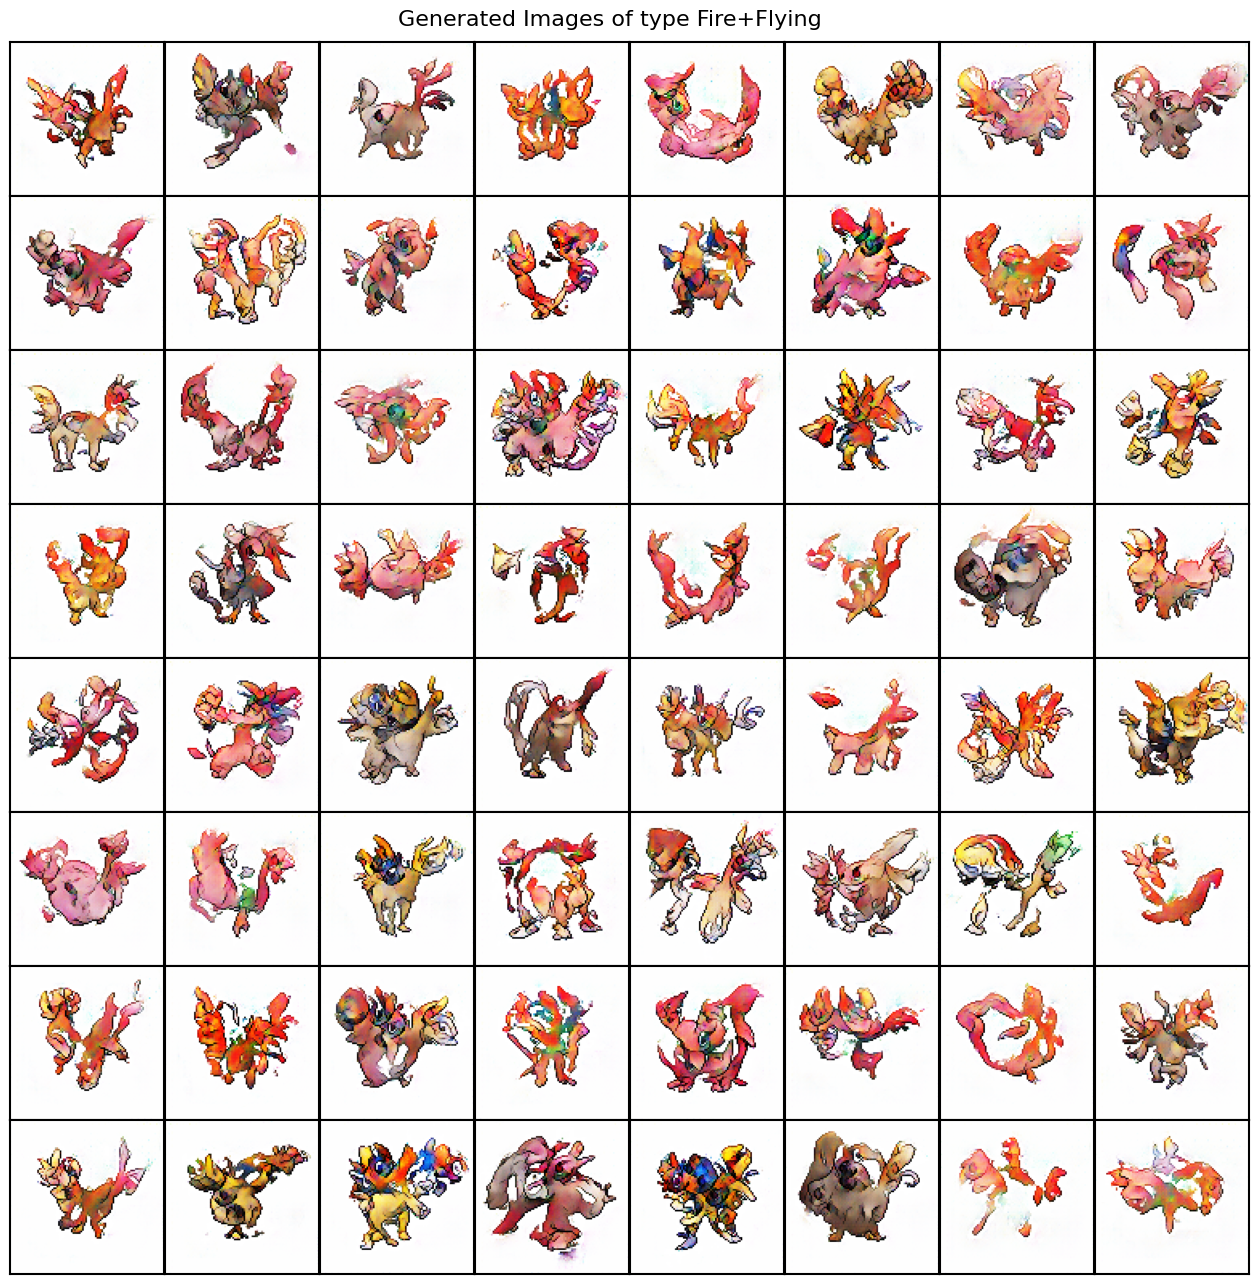

In [130]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERACIÓN DE IMÁGENES — carga de pesos e inferencia
# ─────────────────────────────────────────────────────────────────────────────
#
# Tipos disponibles:
#   Bug, Dark, Dragon, Electric, Fairy, Fighting, Fire, Flying,
#   Ghost, Grass, Ground, Ice, Normal, Poison, Psychic, Rock, Steel, Water
#
# Uso:
#   - generation = ["Fire"]              → Pokémon de tipo único Fuego
#   - generation = ["Fire", "Flying"]    → Pokémon dual-type Fuego + Volador
# ─────────────────────────────────────────────────────────────────────────────

generation = ["Fire", "Flying"]

# ─────────────────────────────────────────────────────────────────────────────
# Cargar pesos del generador
# ─────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

MODEL_PATH = "/kaggle/input/models/danielqueijeiroalbo/pokegan/pytorch/default/1/generator_final.pth"

state_dict = torch.load(MODEL_PATH, map_location=device)
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
generator.load_state_dict(state_dict)
generator.eval()

# ─────────────────────────────────────────────────────────────────────────────
# Generación
# ─────────────────────────────────────────────────────────────────────────────
GRID_SIZE = 8
N = GRID_SIZE * GRID_SIZE

type1 = generation[0]
type2 = generation[1] if len(generation) > 1 else None

# Validar tipos
tipos_validos = list(type_encoder.classes_)
if type1 not in tipos_validos:
    raise ValueError(f"Tipo '{type1}' no válido. Tipos disponibles: {tipos_validos}")
if type2 is not None and type2 not in tipos_validos:
    raise ValueError(f"Tipo '{type2}' no válido. Tipos disponibles: {tipos_validos}")

# Construir vector binarizado de etiquetas: [orientación, tipo1, tipo2, ...]
# Posición 0 = frente/espalda, posiciones 1..N = tipos en orden alfabético
TYPE_LABELS = sorted(list(type_encoder.classes_))
labels_vec = torch.zeros(N, NUM_TYPES + 1).to(device)
labels_vec[:, 0] = 1.                                           # frente
labels_vec[:, 1 + TYPE_LABELS.index(type1)] = 1.               # tipo primario
if type2:
    labels_vec[:, 1 + TYPE_LABELS.index(type2)] = 0.7          # tipo secundario

# Generar ruido y pasar por el generador
noise = torch.randn(N, LATENT_DIM, 1, 1).to(device)            # (N, dim_z, 1, 1)

with torch.no_grad():
    gen_images = generator(noise, labels_vec).detach().cpu()

# Desnormalizar: [-1, 1] -> [0, 1]
gen_images = (gen_images * 0.5 + 0.5).clamp(0, 1)

# Mostrar grid
title = type1 + (f"+{type2}" if type2 else "")
fig, axs = plt.subplots(GRID_SIZE, GRID_SIZE, figsize=(GRID_SIZE * 2, GRID_SIZE * 2))

fig.suptitle(f"Generated Images of type {title}", fontsize=16, y=0.90)

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        idx = i * GRID_SIZE + j
        axs[i][j].imshow(np.transpose(gen_images[idx].numpy(), (1, 2, 0)))
        axs[i][j].set_xticks([])
        axs[i][j].set_yticks([])
        for spine in axs[i][j].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.0, hspace=0.0, top=0.88)

plt.show()
